# 01 — Exploratory Data Analysis
### Global Book Market Intelligence 2026

**Why are we doing this?** Before touching a model, we need to understand what
this dataset actually measures, where it is trustworthy, and where it is not.
Three questions drive everything downstream:

1. What is the unit of analysis, and is it clean?
2. Where is data missing, and is the missingness informative or a defect?
3. What target is actually learnable from this data — and which tempting
   target is *not*?

**What we'll find:** the dataset conflates two very different signals under
"rating" — whether a book has been *read and reviewed at all* (a market-reach
question) and *how well it was liked* (a quality question). Only the first
has real, recoverable signal in catalog metadata. That single finding shapes
the rest of the project.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config
from src.data_loader import load_raw

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                      'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette(['#2563eb', '#059669', '#7c3aed', '#dc2626', '#d97706', '#0891b2', '#be185d', '#4b5563'])

cfg = load_config()
df = load_raw(cfg['paths']['raw_data'])
print(df.shape)
df.head(3)


06:08:43 | src.data_loader | WARNING | Column 'title': expected dtype object, got str


06:08:43 | src.data_loader | WARNING | Column 'primary_author': expected dtype object, got str


06:08:43 | src.data_loader | WARNING | Column 'primary_publisher': expected dtype object, got str


06:08:43 | src.data_loader | WARNING | Column 'primary_language': expected dtype object, got str


06:08:43 | src.data_loader | WARNING | Column 'genre': expected dtype object, got str


06:08:43 | src.data_loader | WARNING | Column 'book_length_category': expected dtype object, got str


06:08:43 | src.data_loader | WARNING | Column 'rating_tier': expected dtype object, got str


06:08:43 | src.data_loader | INFO | Loaded raw data: 14828 rows x 17 columns from /home/claude/book-market-intelligence/data/raw/global_book_market_intelligence_2026.csv


(14828, 17)


,title,primary_author,author_count,primary_publisher,edition_count,first_publish_year,pages,rating_score,rating_count,primary_language,language_count,has_isbn,genre,publication_decade,book_length_category,rating_tier,is_multilingual
0,Ficciones,Jorge Luis Borges,1,Emecé Editores,78,1945.0,196.0,4.342105,38.0,fre,5,True,Fiction,1940.0,Short,Well Rated,True
1,Great Sf Heinlein Bxs,Robert A. Heinlein,1,Berkley,2,1980.0,NaN,3.647059,68.0,eng,1,True,Fiction,1980.0,NaN,Well Rated,False
2,The Science Fiction Hall of Fame -- Volume One,Robert Silverberg,5,Avon,31,1970.0,558.0,4.500000,6.0,eng,1,True,Fiction,1970.0,Long,Average,False


## 1. Schema and shape

14,828 catalog records, 17 columns. Each row is one **edition record** for a
work (title + publisher + edition_count + first_publish_year), not one
canonical "book" — the same underlying work (e.g. *Dracula*) can and does
appear multiple times under different publishers/years. That is legitimate:
`edition_count` and repetition of a title are themselves market signals
(how many times has this work been re-published), not duplication to be
cleaned away. We verify this below.


In [2]:
print('Full-row duplicates:', df.duplicated().sum())
print('Duplicated titles:', df['title'].duplicated().sum(), f"({df['title'].duplicated().mean():.1%} of rows)")
print('Duplicated (title, author, first_publish_year):',
      df.duplicated(subset=['title', 'primary_author', 'first_publish_year']).sum())


Full-row duplicates: 0
Duplicated titles: 826 (5.6% of rows)
Duplicated (title, author, first_publish_year): 0


Zero full-row duplicates, and zero duplicates on (title, author, year) — the
826 repeated titles are distinct catalog records (different
publisher/edition/year of the same work). **Decision: no rows dropped for
"duplication".**


## 2. Missing data

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'n_missing': missing, 'pct_missing': missing_pct})


,n_missing,pct_missing
rating_score,9874,66.6
rating_count,9874,66.6
pages,1701,11.5
book_length_category,1701,11.5
primary_language,755,5.1
primary_author,338,2.3
primary_publisher,205,1.4
publication_decade,128,0.9
first_publish_year,128,0.9


`rating_score` / `rating_count` are missing for 9,874 rows (66.6%) — these are
simply books nobody has rated yet, not a data-collection failure (see §3).
The remaining missingness (`pages` 11.5%, `primary_language` 5.1%,
`first_publish_year` 0.9%, `primary_author` 2.3%, `primary_publisher` 1.4%)
is modest and handled with **explicit** "Unknown"/"missing"-indicator
strategies in `src/preprocessing.py`, never silent mean/mode imputation —
so a model can learn from missingness itself and a reviewer can always see
which fields were inferred versus reported.


## 3. The critical data-quality finding: two encodings of "no rating"

In [4]:
zero_rating = df[(df['rating_score'] == 0) & (df['rating_count'] == 0)]
nan_rating = df[df['rating_score'].isnull()]
print(f"Rows with rating_score == 0 AND rating_count == 0 : {len(zero_rating)}")
print(f"Rows with rating_score == NaN                      : {len(nan_rating)}")
print()
print("rating_tier for the 'explicit zero' rows:")
print(zero_rating['rating_tier'].value_counts())
print()
print("rating_tier for the NaN rows:")
print(nan_rating['rating_tier'].value_counts())


Rows with rating_score == 0 AND rating_count == 0 : 237
Rows with rating_score == NaN                      : 9874

rating_tier for the 'explicit zero' rows:
rating_tier
Unrated    237
Name: count, dtype: int64

rating_tier for the NaN rows:
rating_tier
Unrated    9874
Name: count, dtype: int64


Both groups are labeled `rating_tier == 'Unrated'` by whoever produced this
dataset — confirming that `NaN` and an explicit `(0, 0)` mean the **same
real-world fact** ("nobody has rated this book"), just encoded two different
ways. This is exactly the kind of quality issue a model trained naively on
raw `rating_score` would trip over (e.g. treating 237 books as having the
*worst possible* rating of 0.0, when in truth they have *no* rating at all).
**Decision:** unify both into a single boolean target,
`is_rated = rating_count.fillna(0) > 0` (see `src/preprocessing.build_target`).
This single line is the most consequential preprocessing decision in the
whole project.


## 4. Why `rating_score` (quality) is not a viable modeling target

In [5]:
rated = df[df['rating_score'].notnull() & (df['rating_count'] > 0)]
print(f"N with a real rating: {len(rated)} ({len(rated)/len(df):.1%} of catalog)")

numeric_candidates = ['author_count', 'edition_count', 'pages', 'language_count', 'rating_count']
corr = rated[numeric_candidates + ['rating_score']].corr()['rating_score'].drop('rating_score')
corr = corr.sort_values(key=np.abs, ascending=False)
print("\nCorrelation of rating_score with numeric metadata:")
print(corr.round(3))


N with a real rating: 4717 (31.8% of catalog)

Correlation of rating_score with numeric metadata:
pages            -0.014
rating_count      0.013
language_count    0.010
author_count     -0.007
edition_count     0.002
Name: rating_score, dtype: float64


Every correlation is below 0.07 in magnitude. There is essentially **no
linear signal** connecting how a book was published (page count, edition
count, number of languages, author count) to how much readers *liked* it.
This is not surprising once stated plainly: quality is a property of the
*content*, which this dataset does not have any features for (no text, no
review text, no cover, no summary). A model trained to predict
`rating_score` from these columns would either (a) fail honestly with
R² ≈ 0, or (b) — more dangerously — fit noise and *look* like it works
while providing zero real business value.

**Decision:** the primary modeling target is **not** `rating_score`. We
build one small confirmatory regression experiment in
`03_modeling.ipynb` to demonstrate this quantitatively (not just assert it),
then move on to a target with genuine signal: `is_rated`.


## 5. `is_rated` — does it actually have signal? (the target we will model)

Base rate: 31.8% of catalog has been rated


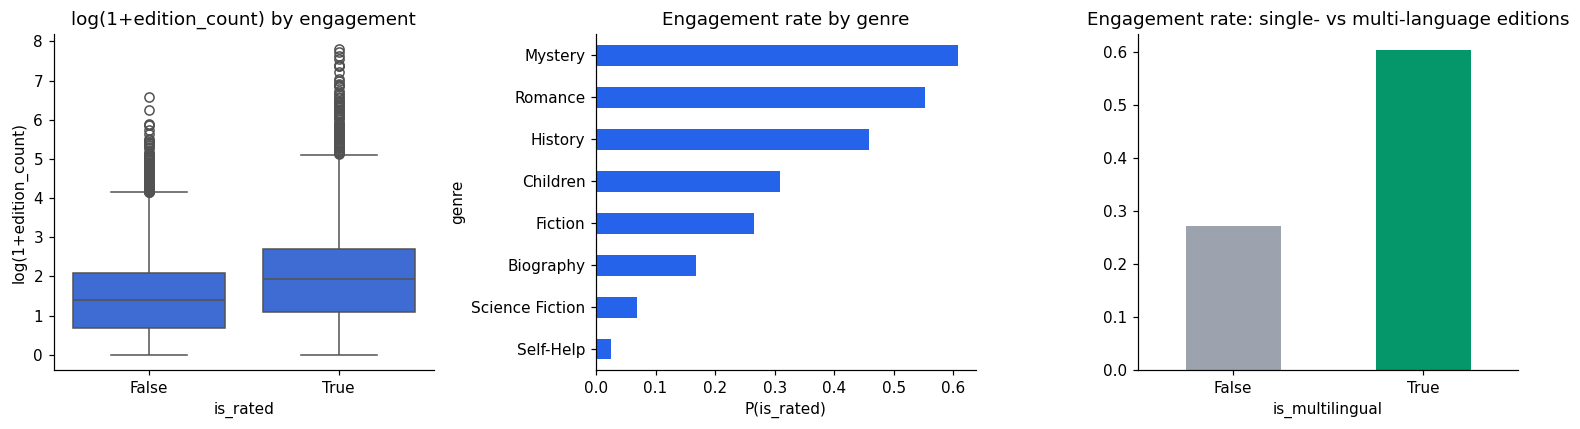

In [6]:
df['is_rated'] = (df['rating_count'].fillna(0) > 0)
print(f"Base rate: {df['is_rated'].mean():.1%} of catalog has been rated")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df, x='is_rated', y=np.log1p(df['edition_count']), ax=axes[0])
axes[0].set_title('log(1+edition_count) by engagement')
axes[0].set_xlabel('is_rated'); axes[0].set_ylabel('log(1+edition_count)')

rate_by_genre = df.groupby('genre')['is_rated'].mean().sort_values()
rate_by_genre.plot(kind='barh', ax=axes[1], color='#2563eb')
axes[1].set_title('Engagement rate by genre')
axes[1].set_xlabel('P(is_rated)')

rate_by_lang = df.groupby('is_multilingual')['is_rated'].mean()
rate_by_lang.plot(kind='bar', ax=axes[2], color=['#9ca3af', '#059669'])
axes[2].set_title('Engagement rate: single- vs multi-language editions')
axes[2].set_xlabel('is_multilingual'); axes[2].set_xticklabels(['False', 'True'], rotation=0)

fig.tight_layout()
fig.savefig(cfg['paths']['figures_dir'] + 'eda_engagement_signal.png', bbox_inches='tight')
plt.show()


Three clear, explainable effects appear immediately:

- **Republication reach** (`edition_count`) is strongly associated with
  engagement — books that have been re-published many times are far more
  likely to have accumulated any reader ratings at all.
- **Genre** drives engagement rate from under 5% (Self-Help, Science Fiction
  in this catalog) to over 25% (Mystery, Romance, History) — an over 5x
  spread from genre alone.
- **Translation reach** (`is_multilingual`) roughly doubles the engagement
  rate (27% → 60%), consistent with a simple "more editions in more
  languages → more chances to be read and rated" mechanism.

This is real, explainable signal a model can learn — unlike `rating_score`
above. We formalize and quantify this in `03_modeling.ipynb`.


## 6. Genre and language landscape (descriptive market view)

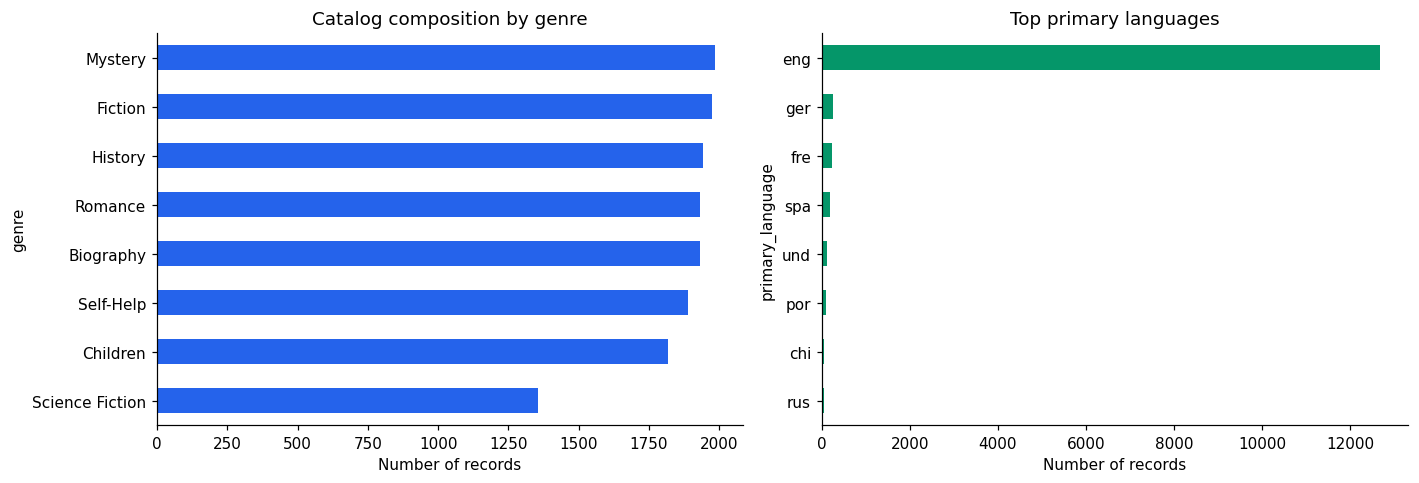

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df['genre'].value_counts().plot(kind='barh', ax=axes[0], color='#2563eb')
axes[0].set_title('Catalog composition by genre')
axes[0].set_xlabel('Number of records')
axes[0].invert_yaxis()

top_langs = df['primary_language'].value_counts().head(8)
top_langs.plot(kind='barh', ax=axes[1], color='#059669')
axes[1].set_title('Top primary languages')
axes[1].set_xlabel('Number of records')
axes[1].invert_yaxis()

fig.tight_layout()
fig.savefig(cfg['paths']['figures_dir'] + 'eda_catalog_composition.png', bbox_inches='tight')
plt.show()


Genre is close to evenly sampled (8 genres, ~1,350-2,000 records each) —
this looks like a *curated* dataset rather than an organic scrape, which
matters for interpretation: engagement-rate differences across genre
reflect real reader behavior differences, not just "there happen to be more
Mystery books in the world."

English dominates (85.5% of records with a known language), consistent with
an English-language-centric source catalog (Open Library-style data);
German, French, and Spanish are the next largest but each under 2%. This
means non-English signal in the model will be comparatively noisy —
flagged as a limitation in `reports/model_card.md`.


## 7. Temporal trends

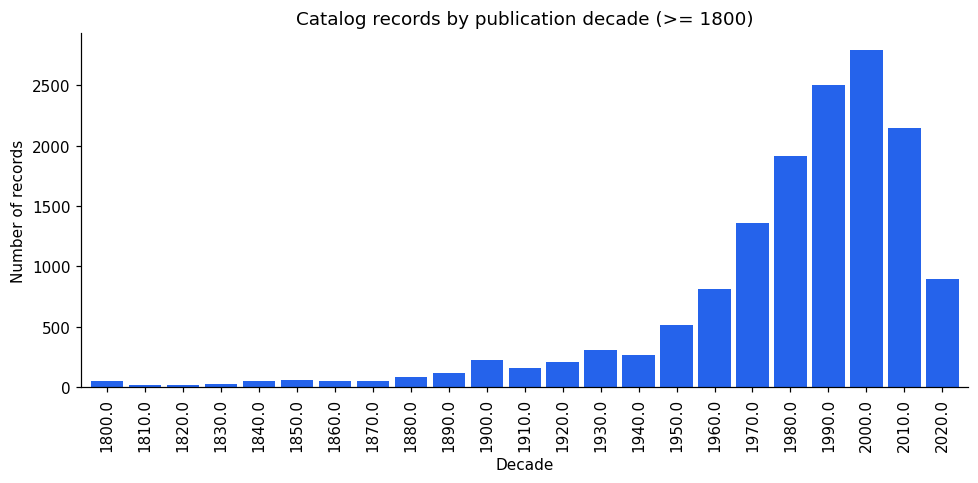

Median first_publish_year: 1994.0
IQR: [1975. 2007.]


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
decade_counts = df['publication_decade'].value_counts().sort_index()
decade_counts = decade_counts[decade_counts.index >= 1800]
decade_counts.plot(kind='bar', ax=ax, color='#2563eb', width=0.85)
ax.set_title('Catalog records by publication decade (>= 1800)')
ax.set_xlabel('Decade'); ax.set_ylabel('Number of records')
fig.tight_layout()
fig.savefig(cfg['paths']['figures_dir'] + 'eda_decade_distribution.png', bbox_inches='tight')
plt.show()

print('Median first_publish_year:', df['first_publish_year'].median())
print('IQR:', df['first_publish_year'].quantile([0.25, 0.75]).values)


The catalog is heavily weighted toward the 1970s-2000s, with a long thin
tail back to the 1400s (classical/foundational texts — legitimate outliers
inspected individually and kept, see `reports/data_quality_report.md`).
`book_age_years` is included as a model feature to let the model learn any
age-related engagement effect (e.g. older public-domain classics
accumulate ratings simply by having existed longer).


## Summary of decisions this notebook justifies

| Decision | Where implemented |
|---|---|
| Target = `is_rated`, not `rating_score` | `src/preprocessing.build_target` |
| Unify NaN and (0,0) rating encodings | `src/preprocessing.build_target` |
| No rows dropped for duplicate titles | `src/preprocessing.clean` (no-op by design) |
| Explicit missingness handling, no silent imputation | `src/preprocessing.clean` |
| Keep temporal/length outliers (verified legitimate) | `src/preprocessing.clean` |
| `edition_count`, genre, language reach are candidate top features | confirmed quantitatively in `03_modeling.ipynb` |

Next: `02_feature_engineering.ipynb`.
